## Importing Libraries

In [3]:
import pandas as pd
import nltk
import re
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

### Downloading NLTK Data

In [4]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /Users/cs-pp/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /Users/cs-pp/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /Users/cs-pp/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /Users/cs-pp/nltk_data...


True

## Loading Dataset

In [5]:
df = pd.read_csv('emotion_balanced.csv')

print(df.head())
print()
print("Shape:", df.shape)

   Unnamed: 0                                               text Emotion
0      833975  i listen to when i feel discouraged as a write...   anger
1      647817  i feel a perverse thrill as i say this despite...   anger
2      148525  i would continue to feel so irritated and even...   anger
3      291010  i feel afraid inside i realize that im angry i...   anger
4      792290  i feel he broke up with his ex for her not tru...   anger

Shape: (4800, 3)


In [9]:
print(df.head())
print()
print("Shape:", df.shape)

                                                text Emotion
0  i listen to when i feel discouraged as a write...   anger
1  i feel a perverse thrill as i say this despite...   anger
2  i would continue to feel so irritated and even...   anger
3  i feel afraid inside i realize that im angry i...   anger
4  i feel he broke up with his ex for her not tru...   anger

Shape: (4800, 2)


## Preprocessing
### Step 1: Lowercasing

In [11]:

df['clean_text'] = df['text'].str.lower()

print(df[['text', 'clean_text']].head(3))

                                                text  \
0  i listen to when i feel discouraged as a write...   
1  i feel a perverse thrill as i say this despite...   
2  i would continue to feel so irritated and even...   

                                          clean_text  
0  i listen to when i feel discouraged as a write...  
1  i feel a perverse thrill as i say this despite...  
2  i would continue to feel so irritated and even...  


### Step 2: Removing Punctuation and Special Characters

In [19]:
df['clean_text'] = df['clean_text'].apply(lambda x: re.sub(r'http\S+|www\S+', '', x))
df['clean_text'] = df['clean_text'].apply(lambda x: re.sub(r'[^a-z\s]', '', x))

print(df[['text', 'clean_text']].head(3))

                                                text  \
0  i listen to when i feel discouraged as a write...   
1  i feel a perverse thrill as i say this despite...   
2  i would continue to feel so irritated and even...   

                                          clean_text  
0  listen feel discouraged writer href http writi...  
1  feel perverse thrill say despite pain arm frig...  
2           would continue feel irritated even angry  


### Step 3: Tokenization

In [20]:

df['clean_text'] = df['clean_text'].apply(lambda x: word_tokenize(x))

print(df[['text', 'clean_text']].head(3))

                                                text  \
0  i listen to when i feel discouraged as a write...   
1  i feel a perverse thrill as i say this despite...   
2  i would continue to feel so irritated and even...   

                                          clean_text  
0  [listen, feel, discouraged, writer, href, http...  
1  [feel, perverse, thrill, say, despite, pain, a...  
2    [would, continue, feel, irritated, even, angry]  


### Step 4: Stop Words Removal

In [21]:

stop_words = stopwords.words('english')
df['clean_text'] = df['clean_text'].apply(lambda x: [word for word in x if word not in stop_words])

print(df[['text', 'clean_text']].head(3))

                                                text  \
0  i listen to when i feel discouraged as a write...   
1  i feel a perverse thrill as i say this despite...   
2  i would continue to feel so irritated and even...   

                                          clean_text  
0  [listen, feel, discouraged, writer, href, http...  
1  [feel, perverse, thrill, say, despite, pain, a...  
2    [would, continue, feel, irritated, even, angry]  


In [22]:
df['clean_text'] = df['clean_text'].apply(lambda x: ' '.join(x))
print(df[['text', 'clean_text']].head(3))

                                                text  \
0  i listen to when i feel discouraged as a write...   
1  i feel a perverse thrill as i say this despite...   
2  i would continue to feel so irritated and even...   

                                          clean_text  
0  listen feel discouraged writer href http writi...  
1  feel perverse thrill say despite pain arm frig...  
2           would continue feel irritated even angry  


### Step 5: Lemmatization

In [23]:
lemmatizer = WordNetLemmatizer()
df['clean_text'] = df['clean_text'].apply(lambda x: ' '.join([lemmatizer.lemmatize(word) for word in x.split()]))
print(df[['text', 'clean_text']].head(3))

                                                text  \
0  i listen to when i feel discouraged as a write...   
1  i feel a perverse thrill as i say this despite...   
2  i would continue to feel so irritated and even...   

                                          clean_text  
0  listen feel discouraged writer href http writi...  
1  feel perverse thrill say despite pain arm frig...  
2           would continue feel irritated even angry  


## Feature Extraction
### TF-IDF Vectorization

In [24]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df['clean_text'])
y = df['Emotion']

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (4800, 5000)
Shape of y: (4800,)


## Train Test Split

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (3840, 5000)
Testing size: (960, 5000)


## Model Training
### Logistic Regression

In [26]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
print("Model trained successfully")

Model trained successfully


## Model Evaluation
### Accuracy Score

In [27]:
from sklearn.metrics import accuracy_score
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", round(accuracy * 100, 2), "%")

Accuracy: 90.94 %


### Confusion Matrix

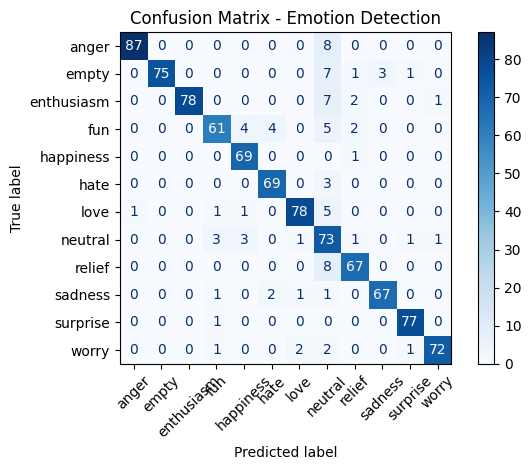

In [28]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title('Confusion Matrix - Emotion Detection')
plt.tight_layout()
plt.show()

## Shopping Customer Service Chatbot
### Defining Emotion Based Responses


In [30]:
from nltk.chat.util import Chat, reflections
import random

emotion_responses = {
    "anger": [
        "We sincerely apologize for your experience! Please share your order ID and we will resolve this immediately 🙏",
        "We are really sorry to hear that! Our team will make this right for you as soon as possible 🙏",
        "We completely understand your frustration and we apologize. Let us fix this for you right away!"
    ],
    "happiness": [
        "That is so wonderful to hear! We are thrilled you are happy with your purchase 😊",
        "Thank you so much! Your happiness means everything to us 😊",
        "We are so glad you are satisfied! Do not forget to leave us a review 🌟"
    ],
    "sadness": [
        "We are really sorry you are feeling this way. How can we make your experience better? 💙",
        "That makes us sad too! Please tell us what went wrong and we will do our best to help 💙",
        "We sincerely apologize for disappointing you. Let us make it up to you 💙"
    ],
    "worry": [
        "No worries at all! We offer free returns so you can shop with confidence 😊",
        "Please do not worry! Our customer support is available 24/7 to help you 😊",
        "We completely understand your concern. Your order is safe with us and we will keep you updated!"
    ],
    "hate": [
        "We are extremely sorry for your terrible experience! Please let us know what happened so we can fix it immediately 🙏",
        "We sincerely apologize! This is not the experience we want for our customers. Let us make it right 🙏",
        "We are so sorry to hear this! Please share your details and our team will resolve this urgently 🙏"
    ],
    "love": [
        "Aww we love you too! Thank you so much for your kind words 💕",
        "That is so sweet! We are so happy you love your purchase 💕",
        "Thank you for the love! We work hard to make our customers happy 💕"
    ],
    "surprise": [
        "Oh we love surprises too! Hope it was a good one 😄",
        "We hope you were pleasantly surprised! Let us know if you need anything 😄",
        "Surprises are the best! We hope your experience exceeded your expectations 😄"
    ],
    "enthusiasm": [
        "We love your energy! We are just as excited to serve you 🎉",
        "Your enthusiasm makes us happy! Let us know how we can help you today 🎉",
        "Yay we are so excited too! Welcome to our store 🎉"
    ],
    "fun": [
        "Shopping should always be fun! Let us know if you need any help 😄",
        "We love that you are having fun! That is what we are here for 😄",
        "Fun and shopping go hand in hand! Enjoy your experience with us 😄"
    ],
    "relief": [
        "We are so relieved too! We always want our customers to be satisfied 😊",
        "That is great to hear! We are glad everything worked out for you 😊",
        "Relief is the best feeling! We are happy we could help you 😊"
    ],
    "empty": [
        "We are sorry you are feeling this way. Is there anything we can help you with today? 💙",
        "We care about how you feel! Please let us know how we can improve your experience 💙",
        "We want to make your day better! Tell us what you need and we will help 💙"
    ],
    "neutral": [
        "Thank you for reaching out! How can we assist you today? 😊",
        "Hello! Welcome to our customer service. How can we help you? 😊",
        "Hi there! Please let us know what you need and we will be happy to help 😊"
    ]
}

print("Emotion responses loaded successfully!")

Emotion responses loaded successfully!


### Chatbot Function


In [31]:
def chatbot():
    print("=" * 50)
    print("Welcome to Shopping Customer Service Chatbot!")
    print("Type 'exit' to quit")
    print("=" * 50)

    while True:
        user_input = input("You: ")

        if user_input.lower() == 'exit':
            print("Chatbot: Thank you for contacting us. Have a great day! 😊")
            break

       
        emotion = predict_emotion(user_input)
        print("Detected Emotion:", emotion)

        # get response based on emotion
        response = random.choice(emotion_responses[emotion])
        print("Chatbot:", response)
        print()

chatbot()

Welcome to Shopping Customer Service Chatbot!
Type 'exit' to quit
Detected Emotion: neutral
Chatbot: Thank you for reaching out! How can we assist you today? 😊

Detected Emotion: neutral
Chatbot: Hello! Welcome to our customer service. How can we help you? 😊

Detected Emotion: anger
Chatbot: We sincerely apologize for your experience! Please share your order ID and we will resolve this immediately 🙏

Detected Emotion: neutral
Chatbot: Hello! Welcome to our customer service. How can we help you? 😊

Detected Emotion: neutral
Chatbot: Hello! Welcome to our customer service. How can we help you? 😊

Chatbot: Thank you for contacting us. Have a great day! 😊


## Saving Model


In [32]:
import joblib
joblib.dump(model, 'emotion_model.pkl')
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')
print("Model and TF-IDF saved successfully!")

Model and TF-IDF saved successfully!
